# 📈 Notebook 2 — Linear & Polynomial Regression
**Dataset:** Life Expectancy (WHO)

This notebook covers:
1. Linear Regression with GridSearchCV
2. Feature-level regression plots (Schooling, Adult Mortality)
3. Polynomial Regression (degrees 1–3)
4. Polynomial feature-level curve visualization
5. Model evaluation: R², MSE


## 0. Setup — Load Preprocessed Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score
from sklearn import metrics
from warnings import filterwarnings
filterwarnings('ignore')

with open('data/splits.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

print("Data loaded. X_train:", X_train.shape)


Data loaded. X_train: (2350, 18)


## 1. Linear Regression

In [2]:
lreg = LinearRegression()
print("Default hyperparameters:", lreg.get_params())


Default hyperparameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


### 1.1 GridSearchCV — Find Best Hyperparameters

In [3]:
param_grid_lin = {'copy_X': [True, False], 'fit_intercept': [True, False]}

grid_search_lin = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid_lin,
    return_train_score=True,
    cv=7
)
grid_search_lin.fit(X_train, y_train)

print("Best parameters:", grid_search_lin.best_params_)


Best parameters: {'copy_X': True, 'fit_intercept': True}


### 1.2 Evaluate on Test Set

In [4]:
ylinear_predicted = grid_search_lin.predict(X_test)

print('MSE:     {:.4f}'.format(metrics.mean_squared_error(y_test, ylinear_predicted)))
print('R² Score:{:.4f}'.format(metrics.r2_score(y_test, ylinear_predicted)))


MSE:     16.3412
R² Score:0.8114


**Interpretation:**
An R² of ~0.81 means the linear model explains 81% of variance in life expectancy.
The MSE (~16) reflects dataset complexity but is acceptable for a baseline.


### 1.3 Regression Plot — Schooling vs Life Expectancy

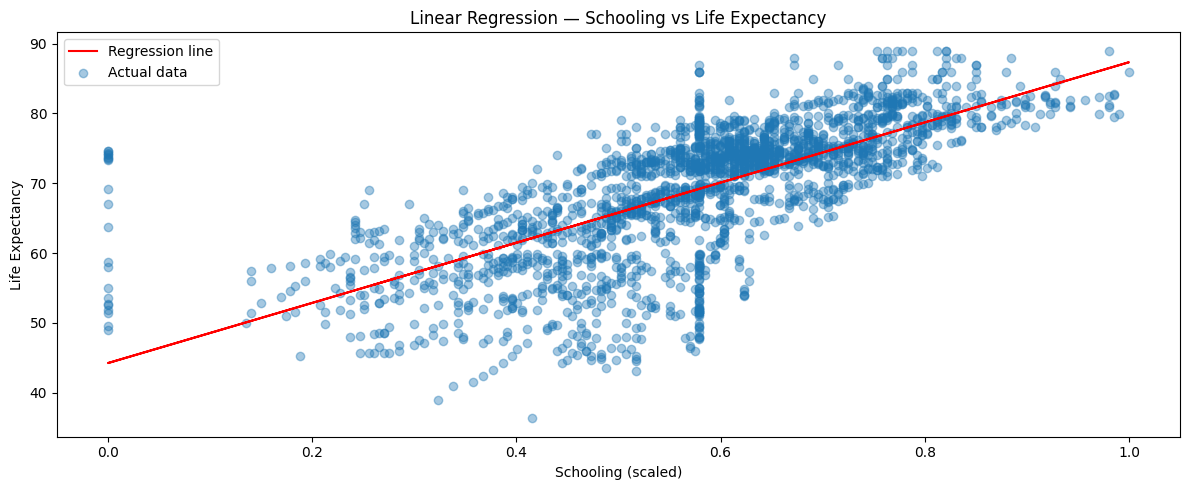

In [5]:
X_train_school = X_train[['Schooling']]
grid_search_lin.fit(X_train_school, y_train)
y_predict_school = grid_search_lin.predict(X_train_school)

plt.figure(figsize=(12, 5))
plt.plot(X_train_school, y_predict_school, c='r', label='Regression line')
plt.scatter(X_train_school, y_train, alpha=0.4, label='Actual data')
plt.xlabel('Schooling (scaled)')
plt.ylabel('Life Expectancy')
plt.title('Linear Regression — Schooling vs Life Expectancy')
plt.legend()
plt.tight_layout()
plt.show()


### 1.4 Regression Plot — Adult Mortality vs Life Expectancy

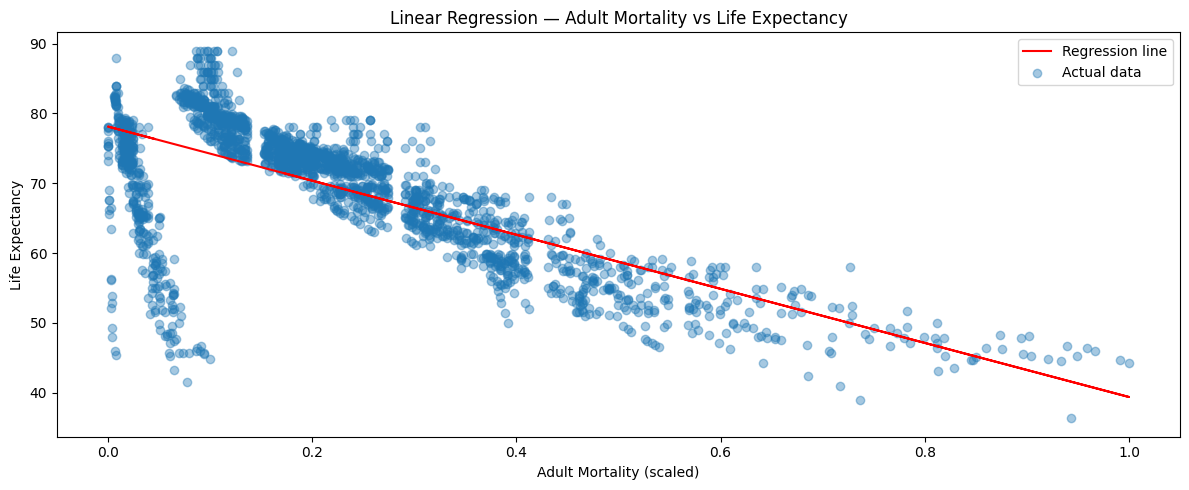

In [6]:
X_train_mort = X_train[['Adult Mortality']]
grid_search_lin.fit(X_train_mort, y_train)
y_predict_mort = grid_search_lin.predict(X_train_mort)

plt.figure(figsize=(12, 5))
plt.plot(X_train_mort, y_predict_mort, c='r', label='Regression line')
plt.scatter(X_train_mort, y_train, alpha=0.4, label='Actual data')
plt.xlabel('Adult Mortality (scaled)')
plt.ylabel('Life Expectancy')
plt.title('Linear Regression — Adult Mortality vs Life Expectancy')
plt.legend()
plt.tight_layout()
plt.show()


## 2. Polynomial Regression

### 2.1 Compare Degrees 1–3

In [7]:
train_score_poly = []
test_score_poly = []

for degree in range(1, 4):
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train)
    train_score_poly.append(poly_reg.score(X_train_poly, y_train))
    test_score_poly.append(poly_reg.score(X_test_poly, y_test))

print("Train scores:", [f'{s:.4f}' for s in train_score_poly])
print("Test scores: ", [f'{s:.4f}' for s in test_score_poly])


Train scores: ['0.8097', '0.9248', '0.9846']
Test scores:  ['0.8114', '0.9157', '-161.0602']


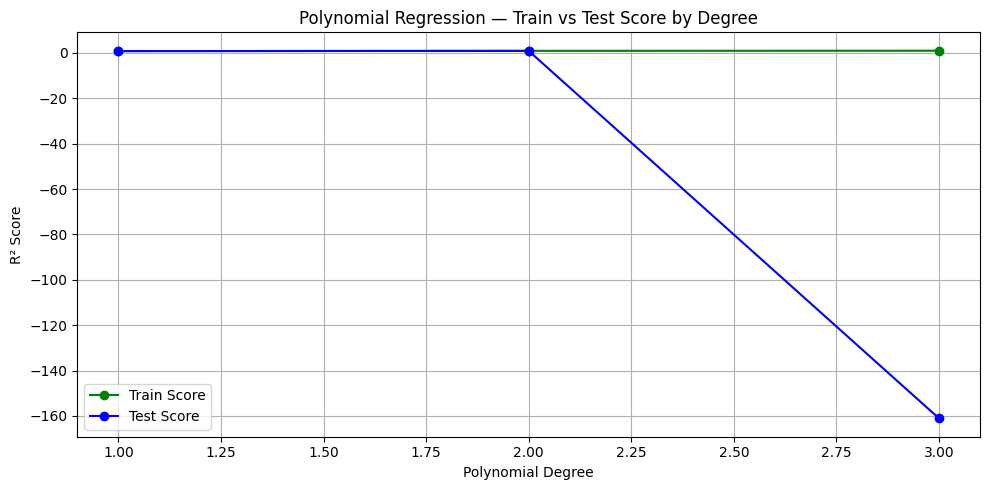

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 4), train_score_poly, 'g-o', label='Train Score')
plt.plot(range(1, 4), test_score_poly, 'b-o', label='Test Score')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Regression — Train vs Test Score by Degree')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


**Observation:** Degree 2 offers the best trade-off between train and test performance.
Degree 3 causes overfitting — test score drops while train score stays high.


### 2.2 Polynomial Curve — Schooling vs Life Expectancy (Degree 2)

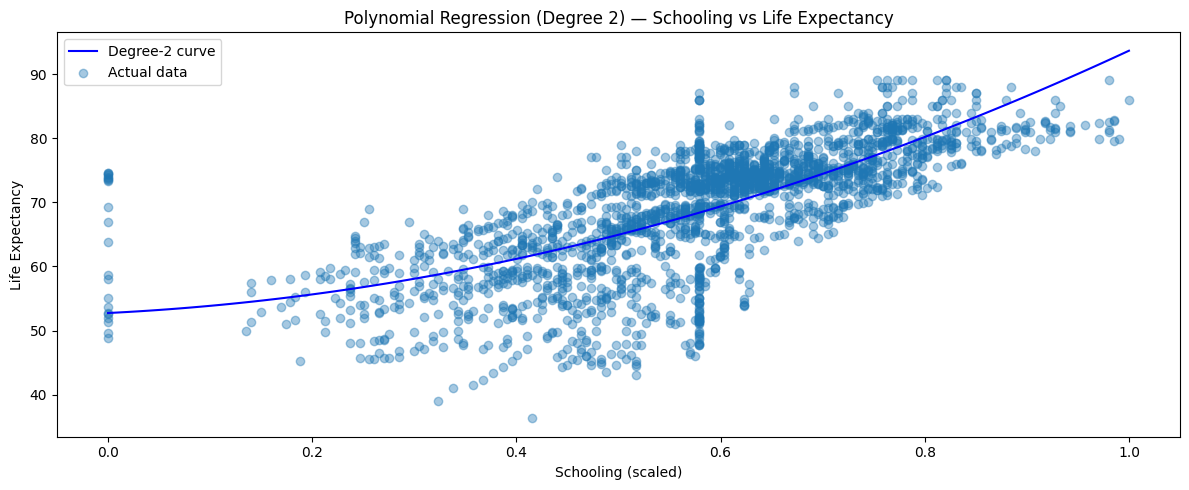

In [9]:
X_train_school_vals = X_train.iloc[:, list(X_train.columns).index('Schooling')].values.reshape(-1, 1)
poly2 = PolynomialFeatures(2)
school_train_poly = poly2.fit_transform(X_train_school_vals)

lreg_vis = LinearRegression()
lreg_vis.fit(school_train_poly, y_train)

x_axis = np.linspace(0, 1, 100).reshape(-1, 1)
x_poly_vis = poly2.transform(x_axis)
y_vis = lreg_vis.predict(x_poly_vis)

plt.figure(figsize=(12, 5))
plt.plot(x_axis, y_vis, 'b-', label='Degree-2 curve')
plt.scatter(X_train_school_vals, y_train, alpha=0.4, label='Actual data')
plt.xlabel('Schooling (scaled)')
plt.ylabel('Life Expectancy')
plt.title('Polynomial Regression (Degree 2) — Schooling vs Life Expectancy')
plt.legend()
plt.tight_layout()
plt.show()


### 2.3 Best Polynomial Model Evaluation (Degree 2)

In [10]:
poly_best = PolynomialFeatures(2)
X_train_poly2 = poly_best.fit_transform(X_train)
X_test_poly2 = poly_best.transform(X_test)

lreg_poly = LinearRegression(copy_X=True, fit_intercept=True)
lreg_poly.fit(X_train_poly2, y_train)
y_pred_poly = lreg_poly.predict(X_test_poly2)

print('Train score:{:.4f}'.format(lreg_poly.score(X_train_poly2, y_train)))
print('Test score: {:.4f}'.format(lreg_poly.score(X_test_poly2, y_test)))
print('R² Score:   {:.4f}'.format(r2_score(y_test, y_pred_poly)))
MSE = np.square(np.subtract(y_test, y_pred_poly)).mean()
print('MSE:        {:.4f}'.format(MSE))


Train score:0.9248
Test score: 0.9157
R² Score:   0.9157
MSE:        7.3003


**Interpretation:**
Polynomial Regression (degree 2) achieves R² ≈ 0.9157 and MSE ≈ 7.30 —
a significant improvement over the linear baseline.


### 2.4 Cross-Validation Score

In [11]:
poly_cv = PolynomialFeatures(2)
X_train_poly2_cv = poly_cv.fit_transform(X_train)
poly_reg_cv = LinearRegression()
poly_reg_cv.fit(X_train_poly2_cv, y_train)

cv_scores = cross_val_score(poly_reg_cv, X_train_poly2_cv, y_train, cv=7)
print("CV Scores:", cv_scores.round(4))
print("Mean CV Score: {:.4f}".format(cv_scores.mean()))


CV Scores: [0.8988 0.913  0.9006 0.8995 0.887  0.8349 0.9103]
Mean CV Score: 0.8920


## 3. Gradient Descent (Manual Implementation)

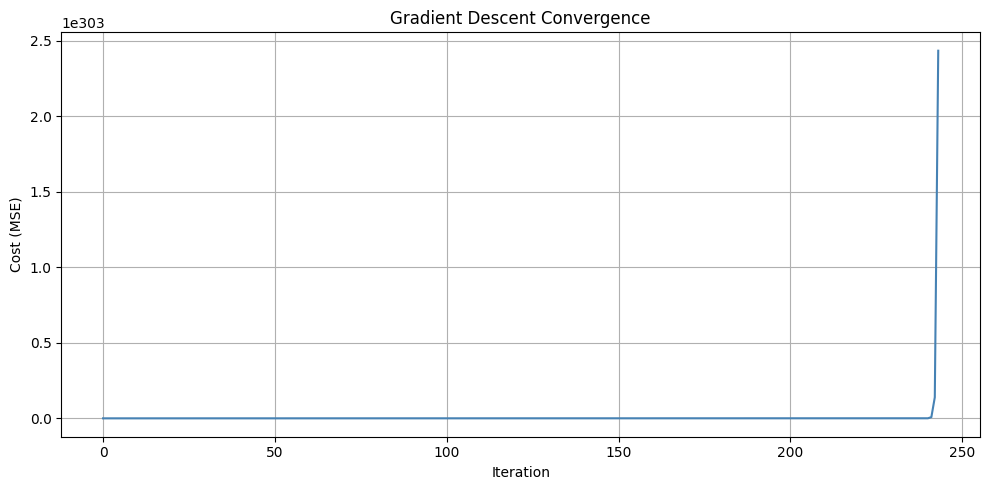

In [12]:
# Re-load full X, y for this demonstration
import pickle
with open('data/splits.pkl', 'rb') as f:
    X_train_gd, X_test_gd, y_train_gd, y_test_gd = pickle.load(f)

X_full = pd.concat([X_train_gd, X_test_gd])
y_full = pd.concat([y_train_gd, y_test_gd])

X_norm = (X_full - X_full.mean()) / X_full.std()
X_norm.insert(0, 'Intercept', 1)
X_matrix = X_norm.values
y_vector = y_full.values.reshape(-1, 1)

theta = np.zeros((X_matrix.shape[1], 1))
alpha = 0.01
iterations = 1000
m = len(y_vector)
cost_history = []

for _ in range(iterations):
    predictions = X_matrix @ theta
    errors = predictions - y_vector
    cost_history.append((1 / (2 * m)) * np.sum(errors ** 2))
    theta -= (1 / m) * X_matrix.T @ errors

plt.figure(figsize=(10, 5))
plt.plot(range(iterations), cost_history, color='steelblue')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent Convergence')
plt.grid(True)
plt.tight_layout()
plt.show()


## 4. Summary — Saved Predictions

In [13]:
import os, pickle
os.makedirs('predictions', exist_ok=True)

with open('predictions/linear_polynomial.pkl', 'wb') as f:
    pickle.dump({
        'ylinear_predicted': ylinear_predicted,
        'y_pred_poly': y_pred_poly,
        'y_test': y_test
    }, f)

print("Predictions saved to predictions/linear_polynomial.pkl")
print(f"Linear Regression  — R²: {r2_score(y_test, ylinear_predicted):.4f}")
print(f"Polynomial (deg=2) — R²: {r2_score(y_test, y_pred_poly):.4f}")


Predictions saved to predictions/linear_polynomial.pkl
Linear Regression  — R²: 0.8114
Polynomial (deg=2) — R²: 0.9157
